In [2]:
import os
print(os.getcwd())

c:\Users\irisz\OneDrive\桌面\IDX Exchange


## Resarch question 1: How does the 30-year fixed mortgage rate affect housing prices across different regions and property types?

Data prepartion

In [ ]:
import pandas as pd

sold_combine = pd.read_csv(
    r"C:\Users\irisz\OneDrive\桌面\IDX Exchange\listings_with_rates_flagged_outliers.csv"
)

print(sold_combine.head())

   OriginalListPrice  ListingKey               ListAgentEmail   CloseDate  \
0          1249888.0  1073295259  sandra.mcfetridge@gmail.com  2024-05-01   
1           650000.0  1073219502              lorijo@tcsn.net  2024-03-15   
2          1025000.0  1073169832         doug@socalmodern.com  2024-05-02   
3           725000.0  1073164974     zachmickelson1@gmail.com  2024-04-30   
4           730000.0  1071104851    Antonio@AntonioMatier.com  2024-04-09   

   ClosePrice ListAgentFirstName ListAgentLastName   Latitude   Longitude  \
0   1262555.0             Sandra        McFetridge  33.477414 -117.664879   
1    650000.0            Lori Jo         Stribling  35.508840 -120.690614   
2    962500.0            Douglas            Kramer  33.812886 -118.097004   
3    725000.0            Zachary         Mickelson  33.740706 -117.888816   
4    730000.0            Antonio            Matier        NaN         NaN   

         UnparsedAddress  ... close_to_original_list_ratio  price_per_sqft

In [4]:
print(sold_combine.columns)

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation', 'TaxYear',
       'BuildingAreaTotal', 'BedroomsTota

Research question 1. How does the 30-year fixed mortgage rate affect housing prices across different regions and property types?

Prepare the data and discover the data

In [6]:
print(sold_combine.shape)


(141996, 99)


Select the relevant columns:

In [8]:
columns = [
    "ClosePrice",
    "rate_30yr_fixed",
    "CloseDate",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "DaysOnMarket",
    "OriginalListPrice",
    "PropertySubType",
    "CountyOrParish",
    "City",
    "PostalCode",
    "ClosePrice_outlier_flag",
    "LivingArea_outlier_flag",
    "DaysOnMarket_outlier_flag"
]

available_columns = [col for col in columns if col in sold_combine.columns]
housing = sold_combine[available_columns].copy()

print(housing.shape)

(141996, 16)


Clean the variables

In [9]:
numeric_columns = [
    "ClosePrice",
    "rate_30yr_fixed",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "DaysOnMarket",
    "OriginalListPrice"
]

for col in numeric_columns:
    if col in housing.columns:
        housing[col] = pd.to_numeric(housing[col], errors="coerce")

housing["CloseDate"] = pd.to_datetime(
    housing["CloseDate"],
    errors="coerce"
)

housing["close_year"] = housing["CloseDate"].dt.year
housing["close_month"] = housing["CloseDate"].dt.month
housing["close_yrmo"] = housing["CloseDate"].dt.to_period("M").astype(str)

Remove missing and clearly invalid records:

In [10]:
housing = housing.dropna(
    subset=[
        "ClosePrice",
        "rate_30yr_fixed",
        "LivingArea",
        "CountyOrParish",
        "PropertySubType",
        "CloseDate"
    ]
)

housing = housing[
    (housing["ClosePrice"] > 0) &
    (housing["LivingArea"] > 0) &
    (housing["rate_30yr_fixed"].between(1, 15))
].copy()

Remove flagged outliers when those columns exist:

In [11]:
outlier_columns = [
    "ClosePrice_outlier_flag",
    "LivingArea_outlier_flag",
    "DaysOnMarket_outlier_flag"
]

for col in outlier_columns:
    if col in housing.columns:
        housing = housing[
            housing[col].fillna(0).astype(int) == 0
        ]

Try to use log price and price per square foot instead of using close price. Becauselarge house naturally costs more

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
housing["price_per_sqft"] = (
    housing["ClosePrice"] / housing["LivingArea"]
)

housing["log_close_price"] = np.log(housing["ClosePrice"])
housing["log_living_area"] = np.log(housing["LivingArea"])

housing = housing[
    housing["price_per_sqft"].between(50, 5_000)
].copy()

In [15]:
monthly_summary = (
    housing.groupby("close_yrmo", as_index=False)
    .agg(
        median_close_price=("ClosePrice", "median"),
        median_price_per_sqft=("price_per_sqft", "median"),
        mortgage_rate=("rate_30yr_fixed", "mean"),
        sales_count=("ClosePrice", "size")
    )
)

monthly_summary = monthly_summary.sort_values("close_yrmo")

print(monthly_summary.head())

  close_yrmo  median_close_price  median_price_per_sqft  mortgage_rate  \
0    2024-01            826000.0             593.824228       6.642500   
1    2024-02            840000.0             578.718108       6.655591   
2    2024-03            806000.0             552.677411       6.723098   
3    2024-04            825000.0             557.896762       6.794091   
4    2024-05            850000.0             577.957454       6.905658   

   sales_count  
0          597  
1         5711  
2        10588  
3        13296  
4         3984  


Plot mortgage rates against median prices:

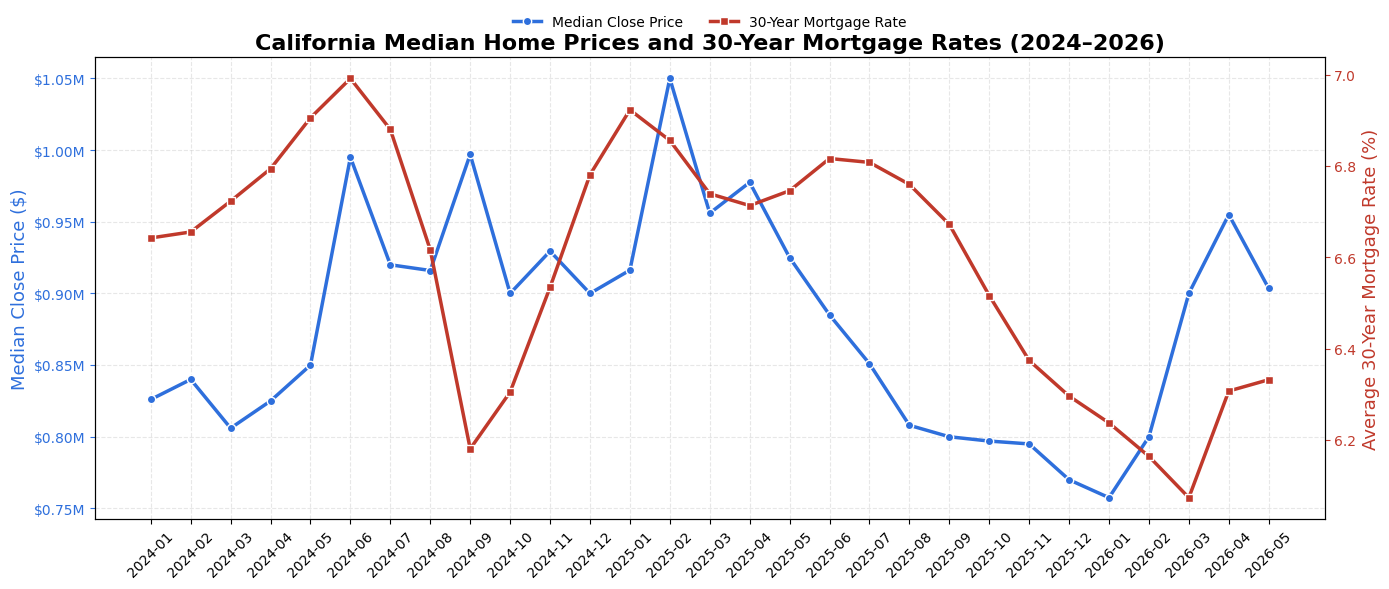

In [19]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(
    monthly_summary["close_yrmo"],
    monthly_summary["median_close_price"],
    color="#2E6FDC",
    linewidth=2.5,
    marker="o",
    markersize=6,
    markeredgecolor="white",
    markeredgewidth=1,
    label="Median Close Price"
)

ax1.set_ylabel("Median Close Price ($)", color="#2E6FDC", fontsize=13)
ax1.tick_params(axis="y", colors="#2E6FDC")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, linestyle="--", alpha=0.3)

from matplotlib.ticker import FuncFormatter
ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1e6:.2f}M')
)

ax2 = ax1.twinx()

ax2.plot(
    monthly_summary["close_yrmo"],
    monthly_summary["mortgage_rate"],
    color="#C0392B",
    linewidth=2.5,
    marker="s",
    markersize=6,
    markeredgecolor="white",
    markeredgewidth=1,
    label="30-Year Mortgage Rate"
)

ax2.set_ylabel("Average 30-Year Mortgage Rate (%)",
               color="#C0392B",
               fontsize=13)

ax2.tick_params(axis="y", colors="#C0392B")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5,1.12),
    ncol=2,
    frameon=False
)

plt.title(
    "California Median Home Prices and 30-Year Mortgage Rates (2024–2026)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Closing Month", fontsize=13)

plt.tight_layout()
plt.show()

## What I learned from the graph: 1. Home prices and mortgage rates do not move in perfect opposite directions

A common expectation is that higher mortgage rates reduce home prices. But the plot suggests the relationship is more complex. For example: January–February 2025: Mortgage rates were near their highest level (~6.9%), yet median home prices also reached their highest point (about $1.05M). Late 2025: Mortgage rates gradually declined from about 6.8% to 6.2%, while median home prices also declined from roughly $920k to $760k. This indicates that mortgage rates alone do not explain price movements.

Additionally Home prices exhibit stronger seasonality than mortgage rates The blue line (median home price) fluctuates substantially throughout the year: Higher prices during spring and early summer Lower prices during autumn and winter. This seasonal pattern is much stronger than the relatively smooth movement in mortgage rates. This suggests that: Seasonal housing demand likely plays an important role in determining prices.Your regression should therefore include month fixed effects 

Mortgage rates changed within a relatively narrow range:During study period: Mortgage rates varied only from about 6.1% to 7.0% Median home prices varied from approximately $760,000 to $1,050,000. Because mortgage-rate variation is modest, large price fluctuations are unlikely to be explained entirely by interest rates.

If mortgage rates had an immediate and strong negative effect, we would expect to observe: Mortgage rates increase Home prices drops. shortly afterward Instead: Several periods show both increasing together. Several periods show both decreasing together. This suggests that the relationship may involve lags or may differ across regions and property types.



## Run Regression model

In [26]:
import sys
print(sys.executable)


c:\Users\irisz\miniconda3\envs\quant\python.exe


In [28]:
import statsmodels.formula.api as smf

basic_model = smf.ols(
    formula="""
        log_close_price ~ rate_30yr_fixed
        + log_living_area
        + BedroomsTotal
        + BathroomsTotalInteger
        + YearBuilt
        + DaysOnMarket
    """,
    data=housing
).fit(cov_type="HC3")

print(basic_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_close_price   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     9035.
Date:                Tue, 14 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:33:26   Log-Likelihood:                -67945.
No. Observations:              118439   AIC:                         1.359e+05
Df Residuals:                  118432   BIC:                         1.360e+05
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                19.59

This estimate log(price)=beta_0+log_beta_1 MortageRate+beta_2livingArea+beta_3BedroomsTotal+beta_4BathroomsTotalInteger+beta_5BathroomsTotalInteger+beta_6YearBuilt+beta_7DaysOnMarket. It means holding house characteristics constant.Although An R² of 0.334 is reasonable for a simple housing model, but it also means about 66.6% of the variation in home prices remains unexplained. This is expected because the model currently does not include location, property type, or time effects, which are major determinants of housing prices. The mortage rate is only 0.0532 Because dependent variable is log(close_price):100×(e
0.0532−1)≈5.5%. It means 1 percentage-point increase in the mortgage rate is associated with approximately 5.5% higher home prices, after controlling for the variables currently in the model. This positive association is opposite to the usual economic expectation that higher borrowing costs reduce housing prices. It indicates that our model likely suffers from omitted variable bias. Mortgage rates were rising during a period when California home prices also remained high, and because the model does not yet account for geography, market conditions, or seasonal effects, the mortgage-rate coefficient is capturing part of those broader market trends rather than an isolated rate effect.

Living area is the strongest predictor of price, with a 1% increase in square footage associated with an estimated 0.76% increase in home value. Properties that remained on the market longer sold for lower prices, indicating that prolonged listing periods may reflect weaker demand. Interestingly, the mortgage-rate coefficient is positive and statistically significant, suggesting that higher mortgage rates are associated with higher observed home prices in this baseline specification. Because the model does not yet control for geographic location, property type, or time-specific market conditions, this coefficient should not be interpreted as a causal effect. Instead, it highlights the need for a more comprehensive model incorporating county, property-type, and temporal fixed effects to better isolate the relationship between mortgage rates and housing prices。

## improve the regression model

use c() means tells Python to treat a variable as a categorical (factor) variable instead of a numeric one.

In [32]:
improve_model = smf.ols(
    formula="""
       log_close_price ~ rate_30yr_fixed
+ log_living_area
+ BedroomsTotal
+ BathroomsTotalInteger
+ YearBuilt
+ DaysOnMarket
+ C(CountyOrParish)
+ C(PropertySubType)
+ C(close_year)
+ C(close_month)
    """,
    data=housing
).fit(cov_type="HC3")

print(improve_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_close_price   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     2546.
Date:                Tue, 14 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:57:46   Log-Likelihood:                -26515.
No. Observations:              118439   AIC:                         5.322e+04
Df Residuals:                  118342   BIC:                         5.416e+04
Df Model:                          96                                         
Covariance Type:                  HC3                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

After I improved the model is much stronger than your baseline model.  R² increased from 0.334 to 0.669, meaning the model now explains 66.9% of the variation in home prices. That is a substantial improvement and shows that location is one of the most important determinants of housing prices. Adding geographic and temporal controls dramatically improves the model's explanatory power, indicating that location and market conditions account for a large share of the variation in California home prices.

I noticed C(CountyOrParish)[T.Butte]      -0.959 C(CountyOrParish)[T.Fresno]     -0.990 C(CountyOrParish)[T.Contra Costa] -0.251
These do not mean those counties have negative home prices.Intead, it mean: After controlling for house size, bedrooms, bathrooms, year built, etc., homes in these counties have lower expected log prices relative to the reference county.

In [33]:
print(sorted(housing["CountyOrParish"].unique()))

['Alameda', 'Amador', 'Butte', 'Calaveras', 'Clark', 'Colusa', 'Contra Costa', 'El Dorado', 'Fresno', 'Glenn', 'Imperial', 'Inyo', 'Kern', 'Kings', 'Lake', 'Lassen', 'Los Angeles', 'Madera', 'Marin', 'Mariposa', 'Mendocino', 'Merced', 'Mono', 'Monterey', 'Napa', 'Nevada', 'Orange', 'Other', 'Other County', 'Other State', 'Placer', 'Plumas', 'Riverside', 'Sacramento', 'San Benito', 'San Bernardino', 'San Diego', 'San Francisco', 'San Joaquin', 'San Luis Obispo', 'San Mateo', 'Santa Barbara', 'Santa Clara', 'Santa Cruz', 'Shasta', 'Sierra', 'Siskiyou', 'Solano', 'Sonoma', 'Stanislaus', 'Sutter', 'Tehama', 'Trinity', 'Tulare', 'Tuolumne', 'Ventura', 'Yolo', 'Yuba']


In [36]:
Santa_clara_model = smf.ols(
    formula="""
       log_close_price ~ rate_30yr_fixed
+ log_living_area
+ BedroomsTotal
+ BathroomsTotalInteger
+ YearBuilt
+ DaysOnMarket
+ C(CountyOrParish,Treatment(reference="Santa Clara"))
+ C(PropertySubType)
+ C(close_year)
+ C(close_month)
    """,
    data=housing
).fit(cov_type="HC3")

print(Santa_clara_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_close_price   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     2536.
Date:                Tue, 14 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:58:26   Log-Likelihood:                -26515.
No. Observations:              118439   AIC:                         5.322e+04
Df Residuals:                  118342   BIC:                         5.416e+04
Df Model:                          96                                         
Covariance Type:                  HC3                                         
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

By default, Patsy uses the alphabetically first category as the reference. If we want a specific county Santa Clara as the reference, we can specify it explicitly:C(CountyOrParish)[T.Fresno] = -1.2690 it means homes in Fresno are estimated to have lower log prices than comparable homes in Santa Clara, holding all other included variables constant.

Nearly every county coefficient has P>|z| = 0.000 meaning  the estimated differences from the reference county are statistically significant. One exception is:Clark p = 0.989.Since p>0.05, its difference from the reference county is not statistically significant. To interperet the a county coefficient, for exmaple,Contra Costa = -0.251 Because the dependent variable is log(price), the exact percentage difference is:100×(e^−0.251−1)=-22.2%.Comparable homes in Contra Costa County are estimated to sell for about 22% less than comparable homes in the reference county. housing prices are highly location-dependent. Two homes with identical:3 bedrooms
2 bathrooms2,000 square feet can differ by over $1 million simply because one is in Silicon Valley and the other is in the Central Valley.Your baseline model ignored this. Adding county fixed effects captures these persistent regional price differences.

 Run seperate statistical model by property type

In [ ]:
def estimate_rate_effect(group):
    if len(group) < 100:
        return pd.Series({
            "observations": len(group),
            "rate_coefficient": np.nan,
            "estimated_price_change_pct": np.nan,
            "p_value": np.nan,
            "r_squared": np.nan
        })

    try:
        model = smf.ols(
            formula="""
                log_close_price ~ rate_30yr_fixed+ log_living_area+ BedroomsTotal + BathroomsTotalInteger+ YearBuilt + DaysOnMarket+ C(CountyOrParish)+ C(close_month)+ C(close_year)
            """,
            data=group
        ).fit(cov_type="HC3")

        coefficient = model.params["rate_30yr_fixed"]

        return pd.Series({
            "observations": int(model.nobs),
            "rate_coefficient": coefficient,
            "estimated_price_change_pct": 100 * (
                np.exp(coefficient) - 1
            ),
            "p_value": model.pvalues["rate_30yr_fixed"],
            "r_squared": model.rsquared
        })

    except Exception:
        return pd.Series({
            "observations": len(group),
            "rate_coefficient": np.nan,
            "estimated_price_change_pct": np.nan,
            "p_value": np.nan,
            "r_squared": np.nan
        })

In [38]:
property_counts = housing["PropertySubType"].value_counts()

major_property_types = property_counts[
    property_counts >= 500
].index

property_data = housing[
    housing["PropertySubType"].isin(major_property_types)
].copy()

In [39]:
property_rate_effects = (
    property_data
    .groupby("PropertySubType")
    .apply(estimate_rate_effect)
    .reset_index()
    .sort_values("estimated_price_change_pct")
)

print(property_rate_effects)

         PropertySubType  observations  rate_coefficient  \
1                 Duplex         565.0         -0.080460   
3  SingleFamilyResidence       87558.0         -0.032094   
0            Condominium       20273.0         -0.019013   
4              Townhouse        7877.0          0.025071   
2     ManufacturedOnLand        1245.0          0.162932   

   estimated_price_change_pct   p_value  r_squared  
1                   -7.730837  0.457786   0.607249  
3                   -3.158483  0.000403   0.658914  
0                   -1.883320  0.285408   0.638682  
4                    2.538777  0.315649   0.599960  
2                   17.695660  0.089526   0.579030  


Holding house characteristics constant, a one-percentage-point increase in the 30-year mortgage rate is associated with approximately a 3.2% decrease in the selling price of single-family homes.This is consistent with economic theory. ,p-value is 0.000 which are statistically significant with a negative negative association. we should keep this factor. ManufacturedOnLand have p value 0.090 which indicates Marginal significance, but estimate is unstable. condominium,Duplex,townhouse have p value larger than 0.05, which indicates they are not statitically significant. 



In summary,The sensitivity of housing prices to mortgage rates varies across property types. Single-family residences exhibit a statistically significant negative relationship, with a one-percentage-point increase in the 30-year mortgage rate associated with an estimated 3.2% decrease in selling price. Although duplexes and condominiums also have negative estimated coefficients, these effects are not statistically significant. Townhouses and manufactured homes display positive coefficients, but neither estimate provides strong statistical evidence of a positive association. Overall, the results suggest that mortgage-rate sensitivity is concentrated primarily in the single-family housing market. we would only focus on the single family type. 

# Run statitsical model by estimate the effect separately by county

In [42]:
county_counts = housing["CountyOrParish"].value_counts()

major_counties = county_counts[
    county_counts >= 1_000
].index

county_data = housing[
    housing["CountyOrParish"].isin(major_counties)
].copy()

In [43]:
def estimate_county_rate_effect(group):
    if len(group) < 500:
        return pd.Series({
            "observations": len(group),
            "rate_coefficient": np.nan,
            "estimated_price_change_pct": np.nan,
            "p_value": np.nan,
            "r_squared": np.nan
        })

    try:
        model = smf.ols(
            formula="""
                log_close_price ~ rate_30yr_fixed
                + log_living_area
                + BedroomsTotal
                + BathroomsTotalInteger
                + YearBuilt
                + DaysOnMarket
                + C(PropertySubType)
                + C(close_month)
                + C(close_year)
            """,
            data=group
        ).fit(cov_type="HC3")

        coefficient = model.params["rate_30yr_fixed"]

        return pd.Series({
            "observations": int(model.nobs),
            "rate_coefficient": coefficient,
            "estimated_price_change_pct": 100 * (
                np.exp(coefficient) - 1
            ),
            "p_value": model.pvalues["rate_30yr_fixed"],
            "r_squared": model.rsquared
        })

    except Exception:
        return pd.Series({
            "observations": len(group),
            "rate_coefficient": np.nan,
            "estimated_price_change_pct": np.nan,
            "p_value": np.nan,
            "r_squared": np.nan
        })

In [44]:
county_rate_effects = (
    county_data
    .groupby("CountyOrParish")
    .apply(estimate_county_rate_effect)
    .reset_index()
    .sort_values("estimated_price_change_pct")
)

print(county_rate_effects)

     CountyOrParish  observations  rate_coefficient  \
3       Los Angeles       27990.0         -0.118968   
10        San Mateo        2075.0         -0.087767   
6         Riverside       13966.0         -0.041341   
7    San Bernardino        9822.0         -0.037737   
8         San Diego       16921.0         -0.028239   
4          Monterey        1132.0         -0.015384   
2      Contra Costa        6851.0          0.010228   
12          Ventura        3644.0          0.013679   
5            Orange       13249.0          0.014110   
0           Alameda        7278.0          0.045843   
11      Santa Clara        5495.0          0.045945   
1             Butte        1137.0          0.062370   
9   San Luis Obispo        1605.0          0.083925   

    estimated_price_change_pct       p_value  r_squared  
3                   -11.216390  2.430198e-11   0.464202  
10                   -8.402614  4.142925e-02   0.659767  
6                    -4.049856  5.081948e-02   0.564867

Los Angeles County have strongest result.It have 27,990 observations. Highly significant p value and have Largest negative coefficient. It means when we are holding house characteristics constant, a one-percentage-point increase in the 30-year mortgage rate is associated with an estimated 11.2% decrease in home prices in Los Angeles County. This aligns well with economic intuition and suggests the Los Angeles market is relatively sensitive to financing costs. Also, we can noticing San Mateo County 2,075 observations with p = 0.041 which are statiscally significant. Although the sample is much smaller than Los Angeles, it still indicating that the San Mateo market also exhibits meaningful mortgage-rate sensitivity. 

Another interesting conty is santa clara. ilicon Valley (Santa Clara) Coefficient:4.7% Statistically significant as p = 0.126 This does not mean:
Higher mortgage rates increase prices in Santa Clara.Instead, it means:After controlling for the variables in your county-specific model, there is no statistically significant evidence of a negative association between mortgage rates and home prices in Santa Clara County. There are few reasons: like High-income buyers relying less on mortgages. Thd buyer tend to use of cash or large down payments.
Persistent demand driven by the technology sector. These are hypotheses that would require additional data to verify.

In summary,The relationship between mortgage rates and housing prices varies substantially across California counties. Los Angeles County exhibits the strongest statistically significant negative association, with a one-percentage-point increase in the 30-year mortgage rate associated with an estimated 11.2% decrease in home prices. San Mateo County also shows a significant negative association of approximately 8.4%. In contrast, several counties—including Santa Clara, Alameda, and Orange—display coefficients that are not statistically distinguishable from zero. These findings suggest that mortgage-rate sensitivity is not uniform across California housing markets and may depend on local market conditions, buyer characteristics, and financing behavior.

Visulization about the county-level sensitivity

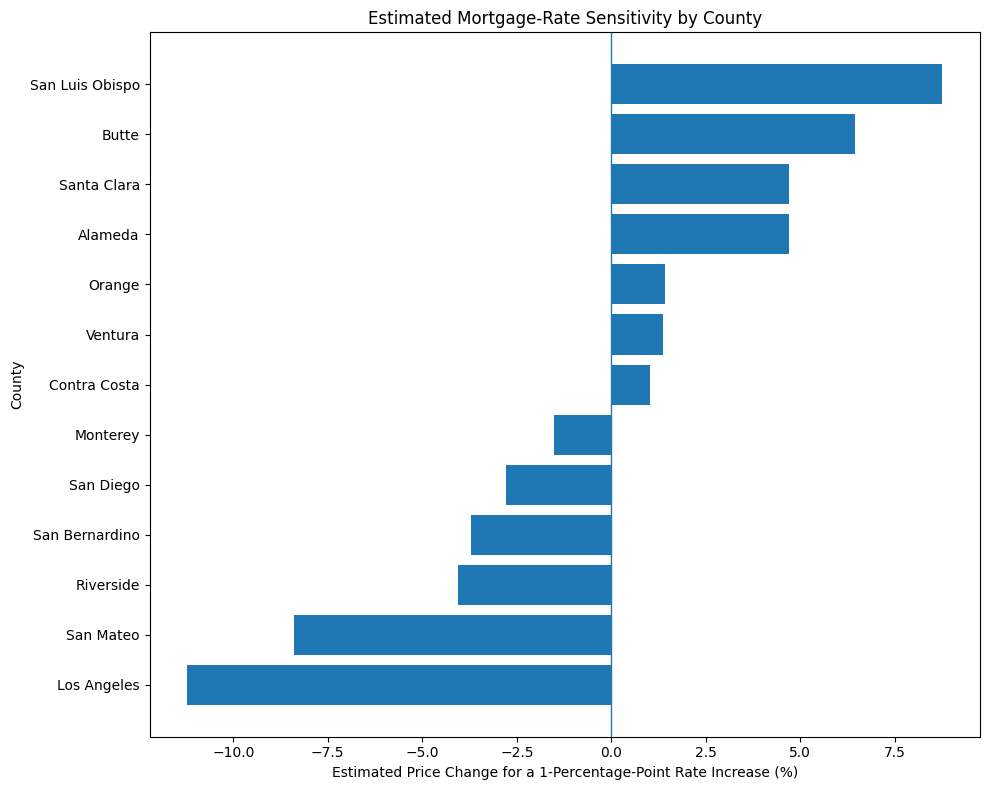

In [45]:
plot_data = county_rate_effects.dropna(
    subset=["estimated_price_change_pct"]
).copy()

plot_data = plot_data.sort_values(
    "estimated_price_change_pct"
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["CountyOrParish"],
    plot_data["estimated_price_change_pct"]
)

plt.axvline(0, linewidth=1)
plt.xlabel(
    "Estimated Price Change for a 1-Percentage-Point Rate Increase (%)"
)
plt.ylabel("County")
plt.title("Estimated Mortgage-Rate Sensitivity by County")
plt.tight_layout()
plt.show()

We can observe that Los Angeles County exhibits the strongest statistically significant negative association, with a one-percentage-point increase in the 30-year mortgage rate associated with an estimated 11.2% decrease in home prices. while San Luis County exhibits the strongest statistically significant postive association, with a one-percentage-point increase in the 30-year mortgage rate associated with an estimated 7.5% in home prices. But it does not statiscally significant. Therefore, we should consider remove this factor as well as the Butte conty. Therefore, we should focus on Santa clara County exhibits the strongest statistically significant postive association, with a one-percentage-point increase in the 30-year mortgage rate associated with an estimated 5% in home prices as it is statistically significant. 

Also, I  find out More negative counties appear more rate-sensitive.Values near zero suggest weaker estimated sensitivity.Positive coefficients require careful investigation and may reflect omitted market trends, limited time variation, or unusual local conditions

Analyze county and property type together

In [46]:
county_property_counts = (
    housing
    .groupby(["CountyOrParish", "PropertySubType"])
    .size()
    .reset_index(name="observations")
)

valid_groups = county_property_counts[
    county_property_counts["observations"] >= 300
][["CountyOrParish", "PropertySubType"]]

county_property_data = housing.merge(
    valid_groups,
    on=["CountyOrParish", "PropertySubType"],
    how="inner"
)

In [47]:
def estimate_group_rate_effect(group):
    try:
        model = smf.ols(
            formula="""
                log_close_price ~ rate_30yr_fixed
                + log_living_area
                + BedroomsTotal
                + BathroomsTotalInteger
                + YearBuilt
                + DaysOnMarket
                + C(close_month)
                + C(close_year)
            """,
            data=group
        ).fit(cov_type="HC3")

        coefficient = model.params["rate_30yr_fixed"]

        return pd.Series({
            "observations": int(model.nobs),
            "rate_coefficient": coefficient,
            "estimated_price_change_pct": 100 * (
                np.exp(coefficient) - 1
            ),
            "p_value": model.pvalues["rate_30yr_fixed"],
            "r_squared": model.rsquared
        })

    except Exception:
        return pd.Series({
            "observations": len(group),
            "rate_coefficient": np.nan,
            "estimated_price_change_pct": np.nan,
            "p_value": np.nan,
            "r_squared": np.nan
        })

In [48]:
county_property_effects = (
    county_property_data
    .groupby(["CountyOrParish", "PropertySubType"])
    .apply(estimate_group_rate_effect)
    .reset_index()
)

county_property_effects["significant_at_5pct"] = (
    county_property_effects["p_value"] < 0.05
)

county_property_effects = county_property_effects.sort_values(
    "estimated_price_change_pct"
)

print(county_property_effects.head(20))

    CountyOrParish        PropertySubType  observations  rate_coefficient  \
7           Fresno  SingleFamilyResidence         371.0         -0.288284   
34      Santa Cruz  SingleFamilyResidence         701.0         -0.201975   
30   Santa Barbara  SingleFamilyResidence         474.0         -0.170264   
10     Los Angeles  SingleFamilyResidence       20547.0         -0.137785   
21  San Bernardino            Condominium         840.0         -0.109154   
28       San Mateo            Condominium         429.0         -0.107534   
4     Contra Costa            Condominium         968.0         -0.104490   
29       San Mateo  SingleFamilyResidence        1444.0         -0.095046   
36         Ventura            Condominium         553.0         -0.067365   
18       Riverside            Condominium        1853.0         -0.067034   
9      Los Angeles            Condominium        5007.0         -0.063832   
11     Los Angeles              Townhouse        2052.0         -0.060759   

What I observed from the result is the relationship between mortgage rates and home prices is highly heterogeneous across California. The magnitude and statistical significance of the mortgage-rate coefficient differ substantially depending on both county and property type. For Fresno Single-Family Homes.A 1-percentage-point increase in mortgage rates is associated with approximately a 25% decrease in the selling price of single-family homes in Fresno.This effect is statistically significant.However, there are only 371 observations.it is based on a relatively small sample, so it may be less stable than estimates from larger counties.Los Angeles Single-Family Home observations	20,547 Price change	-13.8% shows that Single-family homes in Los Angeles appear highly sensitive to mortgage-rate changes.

Also condo markets behave differently across California. it Urban condos rely heavily on financing. Or coastal condo markets may have more investors. Some condo buyers are first-time buyers.Single-family homes are roughly twice as sensitive to mortgage-rate changes as condos and townhouses. That makes economic sense because single-family homes generally have larger loan balances, are purchased by owner-occupiers,
require larger monthly mortgage payments.Therefore financing costs matter more.

Overall, the results suggest that mortgage-rate sensitivity is not uniform across California housing markets.Instead, it varies by both geographic region and housing type. Single-family residences consistently exhibit stronger negative associations with mortgage rates than condominiums or townhouses. In Los Angeles County, where the sample size is large and the relationship is statistically significant, a one-percentage-point increase in mortgage rates is associated with an estimated 13.8% decline in single-family home prices. Similar but generally smaller negative associations are observed for condominiums and townhouses.

Across counties, the magnitude of the estimated effect also differs substantially. Some regions, such as Fresno and Santa Barbara, show larger estimated declines, while others, such as San Diego's condominium market, exhibit little to no measurable association. These findings indicate that the impact of mortgage-rate changes depends on local market conditions and housing segments rather than affecting all California housing markets uniformly.

Visualization of heatmap

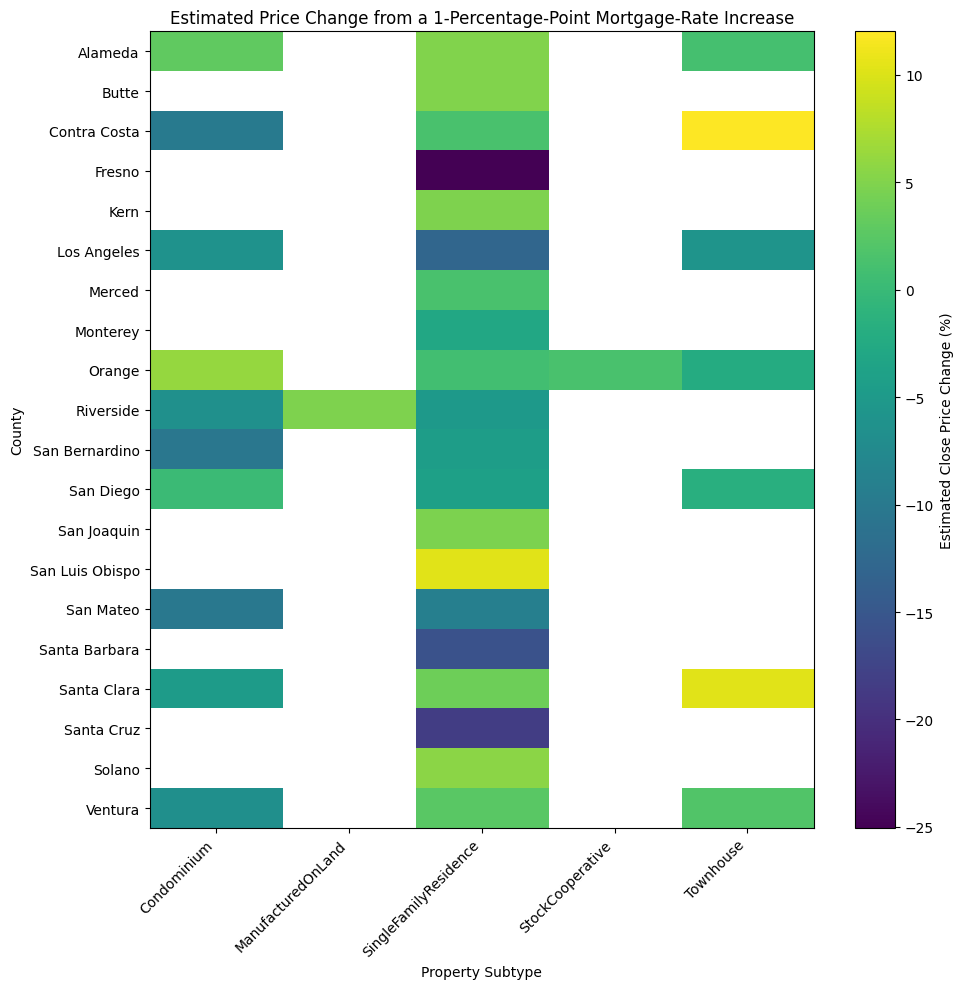

In [49]:
heatmap_data = county_property_effects.pivot(
    index="CountyOrParish",
    columns="PropertySubType",
    values="estimated_price_change_pct"
)

fig, ax = plt.subplots(
    figsize=(max(10, len(heatmap_data.columns) * 2), 10)
)

image = ax.imshow(
    heatmap_data,
    aspect="auto"
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("Property Subtype")
ax.set_ylabel("County")
ax.set_title(
    "Estimated Price Change from a 1-Percentage-Point Mortgage-Rate Increase"
)

fig.colorbar(
    image,
    ax=ax,
    label="Estimated Close Price Change (%)"
)

plt.tight_layout()
plt.show()

I have a finding that Large coefficients from small groups can be less stable than estimates from large groups like Los Angeles. In your report, emphasize the combinations that have both a substantial sample size and statistically significant results, and describe smaller-group findings as suggestive rather than definitive. This will make your conclusions more statistically rigorous.

## Research question 2. What characteristics lead homes to sell within two weeks?

Remove invalid records

In [73]:
# Keep only valid observations
sold = pd.read_csv(r"C:\Users\irisz\OneDrive\桌面\IDX Exchange\sold_with_rates_flagged_outliers.csv")

sold = sold[
    (sold["flag_invalid_dom"] == False) &
    (sold["flag_invalid_livingarea"] == False) &
    (sold["flag_invalid_bedrooms"] == False) &
    (sold["flag_invalid_bathrooms"] == False)
]

print(sold.shape)

C:\Users\irisz\AppData\Local\Temp\ipykernel_5916\2056000644.py:2: DtypeWarning: Columns (62,81,82) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv(r"C:\Users\irisz\OneDrive\桌面\IDX Exchange\sold_with_rates_flagged_outliers.csv")


(413518, 108)


In [74]:
sold["DaysOnMarket"] = pd.to_numeric(
    sold["DaysOnMarket"],
    errors="coerce"
)
sold = sold[
    sold["DaysOnMarket"].notna() &
    (sold["DaysOnMarket"] >= 0)
].copy()

# Target variable
sold["sold_within_14_days"] = (
    sold["DaysOnMarket"] <= 14
).astype(int)

print(sold["sold_within_14_days"].value_counts())
print(sold["sold_within_14_days"].value_counts(normalize=True))

sold_within_14_days
0    231409
1    182109
Name: count, dtype: int64
sold_within_14_days
0    0.55961
1    0.44039
Name: proportion, dtype: float64


Create Target Variable

In [66]:
# Sold within two weeks
sold["sold_within_14_days"] = (
    sold["DaysOnMarket"] <= 14
).astype(int)

print(sold["sold_within_14_days"].value_counts())

sold_within_14_days
0    231409
1    182109
Name: count, dtype: int64


In [75]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

features = [
    "OriginalListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "GarageSpaces",
    "ParkingTotal",
    "FireplacesTotal",
    "Stories",
    "AssociationFee",
    "rate_30yr_fixed",
    "NewConstructionYN",
    "AttachedGarageYN",
    "PropertySubType",
    "CountyOrParish"
]

features = [col for col in features if col in sold.columns]

X = sold[features].copy()
y = sold["sold_within_14_days"].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape)
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Target distribution:")
print(y_train.value_counts(normalize=True))

Training rows: (330814, 98)
Missing values in X_train: 472379
Target distribution:
sold_within_14_days
0    0.559611
1    0.440389
Name: proportion, dtype: float64


train the model with an imputer

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

pred = rf_pipeline.predict(X_test)
prob = rf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))

              precision    recall  f1-score   support

           0       0.64      0.75      0.69     46282
           1       0.59      0.47      0.53     36422

    accuracy                           0.63     82704
   macro avg       0.62      0.61      0.61     82704
weighted avg       0.62      0.63      0.62     82704

ROC AUC: 0.6638840632221265


From the result, we can see the Random Forest model achieved an overall accuracy of 63% and a ROC AUC of 0.664, indicating that the model performed better than random guessing and was able to moderately distinguish between homes that sold within two weeks and those that remained on the market longer.

For homes that actually sold within 14 days, the model achieved a precision of 59%, meaning that when it predicted a property would sell quickly, the prediction was correct approximately six out of ten times. However, the model's recall of 47% indicates that it identified less than half of all fast-selling homes, suggesting that a substantial number of rapid sales were not captured.

Overall, the model demonstrated moderate predictive performance and provides a useful baseline for identifying factors associated with rapid home sales. However, the relatively modest recall and ROC AUC suggest that additional variables or more advanced modeling approaches may improve prediction accuracy.

Feature Importance method

In [80]:
rf_pipeline.fit(X_train, y_train)

pred = rf_pipeline.predict(X_test)
prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [83]:
print("Current X_train columns:", len(X_train.columns))
print("Model feature importances:", len(fitted_rf.feature_importances_))
print("Features used by model:", fitted_rf.n_features_in_)

Current X_train columns: 98
Model feature importances: 97
Features used by model: 97


In [86]:
all_missing_columns = X_train.columns[X_train.isna().all()]

print("Columns containing only NaN:")
print(all_missing_columns.tolist())

Columns containing only NaN:
['FireplacesTotal']


In [88]:
# Remove the completely empty feature
X_train_clean = X_train.drop(columns=["FireplacesTotal"])
X_test_clean = X_test.drop(columns=["FireplacesTotal"])

print("Training features:", X_train_clean.shape[1])
print("Testing features:", X_test_clean.shape[1])

Training features: 97
Testing features: 97


In [89]:
rf_pipeline.fit(X_train_clean, y_train)

fitted_rf = rf_pipeline.named_steps["model"]

print("Model features:", fitted_rf.n_features_in_)

Model features: 97


Importance Table

In [90]:
importance = pd.DataFrame({
    "Feature": X_train_clean.columns,
    "Importance": fitted_rf.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(importance.head(20))

                          Feature  Importance
0               OriginalListPrice    0.160300
1                      LivingArea    0.151523
2               LotSizeSquareFeet    0.142321
3                       YearBuilt    0.130440
4                 rate_30yr_fixed    0.116878
5                  AssociationFee    0.075013
6                    ParkingTotal    0.039590
7                   BedroomsTotal    0.033669
8           BathroomsTotalInteger    0.025212
9                    GarageSpaces    0.020376
10                        Stories    0.010594
11       CountyOrParish_Riverside    0.009019
12          AttachedGarageYN_True    0.008165
13     CountyOrParish_Los Angeles    0.006015
14      NewConstructionYN_Unknown    0.005983
15       AttachedGarageYN_Unknown    0.005288
16     CountyOrParish_Santa Clara    0.005099
17       CountyOrParish_San Diego    0.004836
18          CountyOrParish_Orange    0.004075
19  CountyOrParish_San Bernardino    0.004015


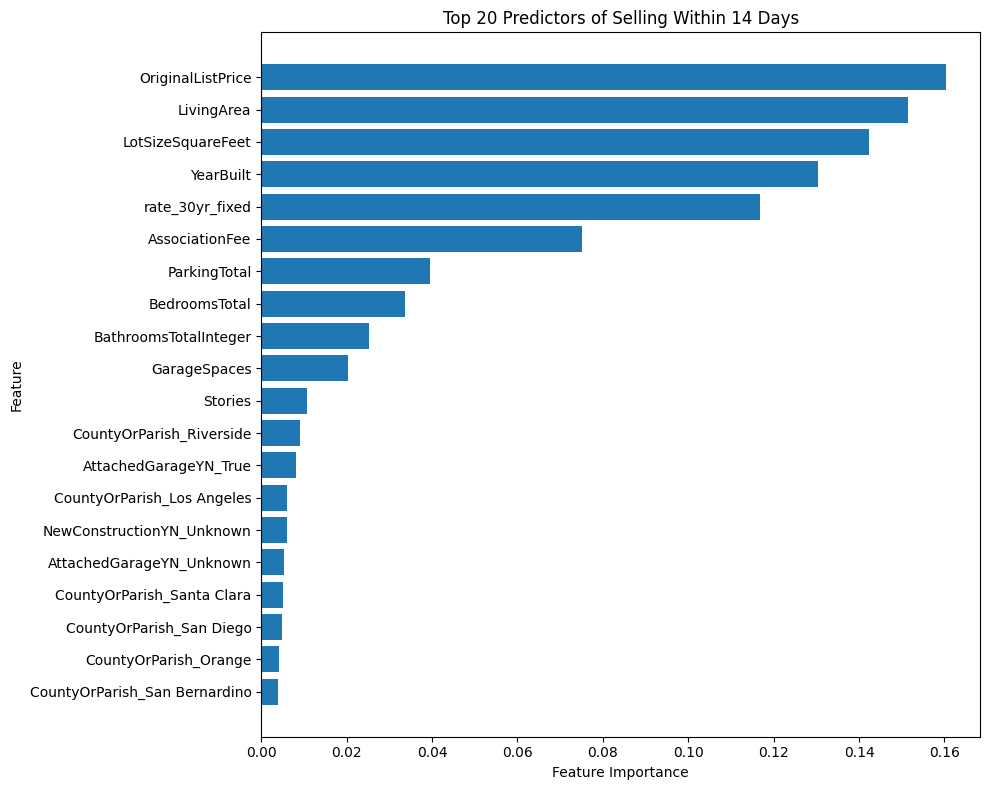

In [92]:
import matplotlib.pyplot as plt

top20 = importance.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(top20["Feature"], top20["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Predictors of Selling Within 14 Days")
plt.tight_layout()
plt.show()

The Random Forest model identified Original List Price as the most influential predictor of whether a home sold within two weeks, followed by Living Area, Lot Size, Year Built, and the 30-year fixed mortgage rate. These findings suggest that pricing strategy, property size, home age, and prevailing market conditions are the primary factors associated with rapid home sales. Property-specific characteristics such as the number of bedrooms, bathrooms, parking spaces, and garage spaces contributed additional predictive value but were less influential. Geographic location, represented by county indicators, had comparatively smaller importance once property and market characteristics were considered.